# Exploración inicial del dataset, Evaluación de calidad de datos, Análisis de distribución de variables del Dataset PFDA_rides

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

In [73]:
# Cargar dataset
df_rides = pd.read_csv('PFDA_rides.csv')

In [ ]:
# el dataset tiene 693071 registros y 10 columnas
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  float64
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  int64  
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [75]:
df_rides.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [76]:
# transformación time_stamp a tipo datetime
df_rides['time_stamp'] = pd.to_datetime(df_rides['time_stamp'], unit ='ms') 

In [77]:
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          693071 non-null  float64       
 1   cab_type          693071 non-null  object        
 2   time_stamp        693071 non-null  datetime64[ns]
 3   destination       693071 non-null  object        
 4   source            693071 non-null  object        
 5   price             637976 non-null  float64       
 6   surge_multiplier  693071 non-null  int64         
 7   id                693071 non-null  object        
 8   product_id        693071 non-null  object        
 9   name              693071 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 52.9+ MB


In [78]:
df_rides

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
...,...,...,...,...,...,...,...,...,...,...
693066,1.00,Uber,2018-12-02 00:20:00,North End,West End,13.0,1,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
693067,1.00,Uber,2018-12-02 00:20:00,North End,West End,9.5,1,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
693068,1.00,Uber,2018-12-02 00:20:00,North End,West End,NaN,1,64d451d0-639f-47a4-9b7c-6fd92fbd264f,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693069,1.00,Uber,2018-12-02 00:20:00,North End,West End,27.0,1,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


In [124]:
df_rides['product_id'].value_counts()

product_id
6f72dfc5-27f1-42e8-84db-ccc7a75f6969    55096
9a0e7b09-b92b-4c41-9779-2ad22b4d779d    55096
6d318bcc-22a3-4af6-bddd-b409bfce1546    55096
6c84fd89-3f11-4782-9b50-97c468b19529    55095
8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a    55095
55c66225-fbe7-4fd5-9072-eab1ece5e23e    55094
997acbb5-e102-41e1-b155-9df7de0a73f2    55091
lyft_premier                            51235
lyft_luxsuv                             51235
lyft                                    51235
lyft_plus                               51235
lyft_lux                                51235
lyft_line                               51233
Name: count, dtype: int64

In [ ]:
# Estadísticas descriptivas
df_rides[['distance', 'price', 'surge_multiplier']].describe()

,distance,price,surge_multiplier
count,693071.000000,637976.000000,693071.000000
mean,2.189430,16.545125,1.014287
std,1.138937,9.324359,0.118818
min,0.020000,2.500000,1.000000
25%,1.280000,9.000000,1.000000
50%,2.160000,13.500000,1.000000
75%,2.920000,22.500000,1.000000
max,7.860000,97.500000,3.000000


In [81]:
# Registros duplicados
df_rides.duplicated().sum()

np.int64(0)

In [80]:
# Valores nulos por columna - RIDES
null_rides = df_rides.isnull().sum()
null_rides_pct = (df_rides.isnull().sum() / len(df_rides)) * 100
null_summary_rides = pd.DataFrame({
    'Valores_Nulos': null_rides,
    'Porcentaje_Nulos': null_rides_pct.round(2)
})
null_summary_rides.sort_values(by='Porcentaje_Nulos', ascending=False)

,Valores_Nulos,Porcentaje_Nulos
price,55095,7.95
distance,0,0.00
cab_type,0,0.00
time_stamp,0,0.00
destination,0,0.00
source,0,0.00
surge_multiplier,0,0.00
id,0,0.00
product_id,0,0.00
name,0,0.00


In [ ]:
#verificar outliers rides respecto a distancia del viaje
Q1_ride = df_rides['distance'].quantile(0.25)
Q3_ride = df_rides['distance'].quantile(0.75)
IQR_ride = Q3_ride - Q1_ride
limite_inferior_ride = Q1_ride - (1.5*IQR_ride)
limite_superior_ride = Q3_ride + (1.5*IQR_ride)

outliers_ride = df_rides[(df_rides['distance'] < limite_inferior_ride) | (df_rides['distance'] > limite_superior_ride)]
outliers_ride

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
515,7.46,Uber,2018-12-13 11:20:00,Northeastern University,Financial District,NaN,1,797848bb-3e80-41a2-a997-ffdc294530eb,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
516,7.46,Uber,2018-12-13 11:20:00,Northeastern University,Financial District,16.0,1,eeae82c8-83e0-44e8-bf70-8e5eb8fb83e4,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV
1977,5.56,Uber,2018-12-03 15:13:20,Boston University,Financial District,12.5,1,4346c8f4-c5f8-40b3-9e08-24104f0719ef,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool
1978,5.56,Uber,2018-12-03 15:13:20,Boston University,Financial District,15.0,1,4e9681fe-f88b-42d5-9fc1-5d2282846777,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV
1979,5.56,Uber,2018-12-03 15:13:20,Boston University,Financial District,15.0,1,75d0f44f-3985-467d-a8a4-1df97c2e8d25,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
...,...,...,...,...,...,...,...,...,...,...
693005,7.36,Uber,2018-11-29 16:46:40,North End,Back Bay,14.5,1,1d31ef5f-2637-46e0-93cf-8d0fe3073b17,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool
693006,7.36,Uber,2018-11-29 16:46:40,North End,Back Bay,36.0,1,39544c00-20c2-4a8c-9248-5818d37c4af9,6c84fd89-3f11-4782-9b50-97c468b19529,Black
693007,7.36,Uber,2018-11-29 16:46:40,North End,Back Bay,49.5,1,c12672b4-2a17-422a-a72f-815d4ed75281,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV
693008,7.36,Uber,2018-11-29 16:46:40,North End,Back Bay,16.0,1,c20c7f8f-036c-41ec-9f08-dd19576cc324,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX


In [84]:
#verificar outliers rides respecto a surge_multiplier: factor de incremento por alta demanda.
Q1_ride = df_rides['surge_multiplier'].quantile(0.25)
Q3_ride = df_rides['surge_multiplier'].quantile(0.75)
IQR_ride = Q3_ride - Q1_ride
limite_inferior_ride = Q1_ride - (1.5*IQR_ride)
limite_superior_ride = Q3_ride + (1.5*IQR_ride)

outliers_ride = df_rides[(df_rides['surge_multiplier'] < limite_inferior_ride) | (df_rides['surge_multiplier'] > limite_superior_ride)]
outliers_ride

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
705,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,42.5,2,46c02b41-6f51-43ab-a389-21d704cac2db,lyft_plus,Lyft XL
706,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,52.5,2,6c187b77-cfab-4fc2-87ae-ce6caf756e35,lyft_lux,Lux Black
707,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,67.5,2,77644bac-cb00-4368-8aef-a3d0fd7861c2,lyft_luxsuv,Lux Black XL
708,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,38.0,2,78695f94-063c-4ea0-9c5d-66b8a0d67f01,lyft_premier,Lux
709,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,22.5,2,9c5c0e40-a5b9-4866-a77b-f4e9bf7eee84,lyft,Lyft
...,...,...,...,...,...,...,...,...,...,...
692257,3.00,Lyft,2018-12-14 04:00:00,North End,Back Bay,22.5,2,1b52c270-f898-45ce-b001-0df6834b3319,lyft,Lyft
692258,3.00,Lyft,2018-12-14 04:00:00,North End,Back Bay,38.5,2,2124e2c4-bafa-4953-b280-038ff12c2f6c,lyft_premier,Lux
692259,3.00,Lyft,2018-12-14 04:00:00,North End,Back Bay,55.0,2,8a0d1d10-8458-4bc2-942f-9249d2acdd7f,lyft_lux,Lux Black
692260,3.00,Lyft,2018-12-14 04:00:00,North End,Back Bay,65.0,2,c63e12f6-24b7-47f8-a8c1-f0a9cdac32bc,lyft_luxsuv,Lux Black XL


In [85]:
#verificar outliers rides respecto a precio estimado del viaje
Q1_ride = df_rides['price'].quantile(0.25)
Q3_ride = df_rides['price'].quantile(0.75)
IQR_ride = Q3_ride - Q1_ride
limite_inferior_ride = Q1_ride - (1.5*IQR_ride)
limite_superior_ride = Q3_ride + (1.5*IQR_ride)

outliers_ride = df_rides[(df_rides['price'] < limite_inferior_ride) | (df_rides['price'] > limite_superior_ride)]
outliers_ride

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
706,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,52.5,2,6c187b77-cfab-4fc2-87ae-ce6caf756e35,lyft_lux,Lux Black
707,3.25,Lyft,2018-12-02 05:53:20,Back Bay,South Station,67.5,2,77644bac-cb00-4368-8aef-a3d0fd7861c2,lyft_luxsuv,Lux Black XL
769,4.76,Lyft,2018-11-27 00:53:20,Boston University,Theatre District,45.5,1,8e4bd9d1-d823-4f20-8dca-42d22da91002,lyft_luxsuv,Lux Black XL
1094,4.31,Lyft,2018-12-16 00:26:40,Fenway,Theatre District,45.5,1,3bebdd9d-17d7-47e0-9d92-2a08a56693d3,lyft_luxsuv,Lux Black XL
1318,5.33,Lyft,2018-12-17 20:53:20,Boston University,Financial District,45.5,1,91182a5d-dc85-4870-acb3-bc31604d15ab,lyft_luxsuv,Lux Black XL
...,...,...,...,...,...,...,...,...,...,...
692439,5.56,Uber,2018-11-29 00:06:40,Boston University,Financial District,47.0,1,ec85457f-b575-42a8-8ff7-8bdf2ee666a8,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV
692698,4.58,Lyft,2018-11-27 06:26:40,Fenway,Financial District,52.5,1,1d2bc447-5fcf-4fa0-a4fc-5838e07abeff,lyft_luxsuv,Lux Black XL
692891,5.42,Lyft,2018-11-30 09:26:40,Boston University,Financial District,47.5,1,f10c8d27-d2c9-4e16-9762-1d35fdd56561,lyft_luxsuv,Lux Black XL
692962,7.36,Uber,2018-11-29 16:46:40,North End,Back Bay,51.0,1,006c270a-bfa8-450f-9628-2d6667e55560,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


In [86]:
#nombre por precio
precio_nombre = df_rides.groupby("name")['price'].agg(['count','median','std', 'min','max'])
precio_nombre

,count,median,std,min,max
name,,,,,
Black,55095,19.5,4.952030,13.5,68.5
Black SUV,55096,28.5,4.836097,23.0,89.5
Lux,51235,16.5,5.291983,10.5,55.0
Lux Black,51235,22.5,6.472883,16.5,75.0
Lux Black XL,51235,30.0,7.181094,26.0,97.5
Lyft,51235,9.0,2.530305,5.0,38.5
Lyft XL,51235,13.5,4.555513,9.0,65.0
Shared,51233,7.0,2.107730,2.5,22.5
Taxi,0,NaN,NaN,NaN,NaN


In [ ]:
#determinar cuantos registros tiene la categoria Taxi para corroborar el valor de nulos anteriormente expuesto con el valor correspondiente a Taxi
df_rides[df_rides['name']=='Taxi'].shape[0]

55095

In [88]:
# visualizar los datos 
df_rides[df_rides['price'].isnull()]

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
18,1.11,Uber,2018-11-28 01:53:20,West End,North End,NaN,1,fa5fb705-03a0-4eb9-82d9-7fe80872f754,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
31,2.48,Uber,2018-11-29 02:53:20,South Station,Beacon Hill,NaN,1,eee70d94-6706-4b95-a8ce-0e34f0fa8f37,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
40,2.94,Uber,2018-11-26 05:26:40,Fenway,North Station,NaN,1,7f47ff53-7cf2-4a6a-8049-83c90e042593,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
60,1.16,Uber,2018-11-30 15:00:00,West End,North End,NaN,1,43abdbe4-ab9e-4f39-afdc-31cfa375dc25,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
69,2.67,Uber,2018-11-28 18:33:20,Beacon Hill,North End,NaN,1,80db1c49-9d51-4575-a4f4-1ec23b4d3e31,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
...,...,...,...,...,...,...,...,...,...,...
693025,2.50,Uber,2018-12-14 04:00:00,Beacon Hill,South Station,NaN,1,70ad9983-92dd-4cdf-af16-732e7e9ee9d0,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693047,0.91,Uber,2018-11-29 02:53:20,Beacon Hill,Haymarket Square,NaN,1,84e05ef0-781a-4bd5-a593-bbbf659d4ba0,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693049,1.79,Uber,2018-11-29 02:53:20,Beacon Hill,North End,NaN,1,885ef635-299e-45cf-8052-c45a39e9822a,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693060,1.61,Uber,2018-12-02 05:53:20,Haymarket Square,Theatre District,NaN,1,50a7b6be-ed2a-4a11-8d36-73bd977ad66a,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi


In [ ]:
#Creamos dataframe para los tipo de empresa (Uber o Lyft)
rides_cab_type_df = pd.DataFrame(df_rides["cab_type"].value_counts()).reset_index()
rides_cab_type_df.rename(columns={"count": "Freq"}, inplace= True)
px.bar(rides_cab_type_df, x = "cab_type", y = "Freq",
    title="Distribución por tipos de empresa")

In [93]:
#Creamos la distribución por el destino
ride_destination_df = pd.DataFrame(df_rides.groupby("destination")["price"].mean()).reset_index()
ride_destination_df = ride_destination_df.sort_values(by = "price", ascending= False)
px.bar(ride_destination_df, x = "destination", y = "price",
    title="Distribución por destino")

In [94]:
#Hacemos un diagrama de barras para los names
ride_name_df = pd.DataFrame(df_rides.groupby("name")["price"].mean()).reset_index()
ride_name_df = ride_name_df.sort_values(by = "price", ascending= False)
px.bar(ride_name_df, x = "name", y = "price",
    title="Distribución por nombres")

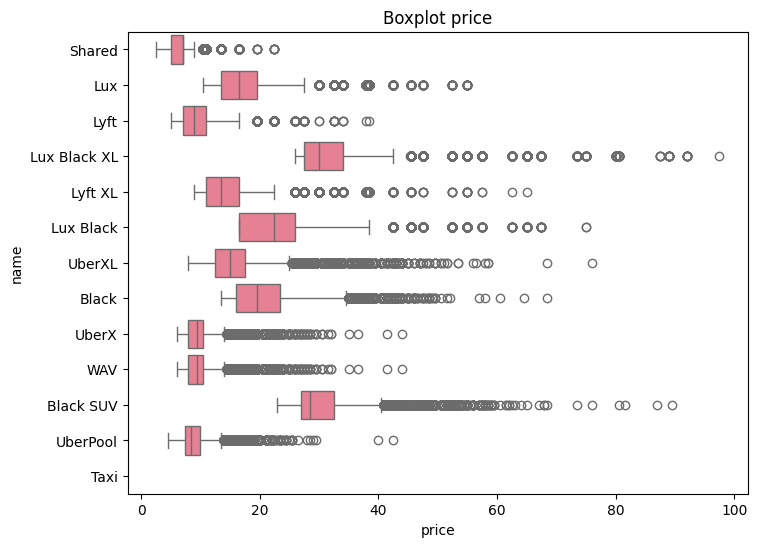

In [95]:
plt.figure(figsize=(8,6))
sns.boxplot(x="price", y="name", data=df_rides)
plt.title("Boxplot price")
plt.show()

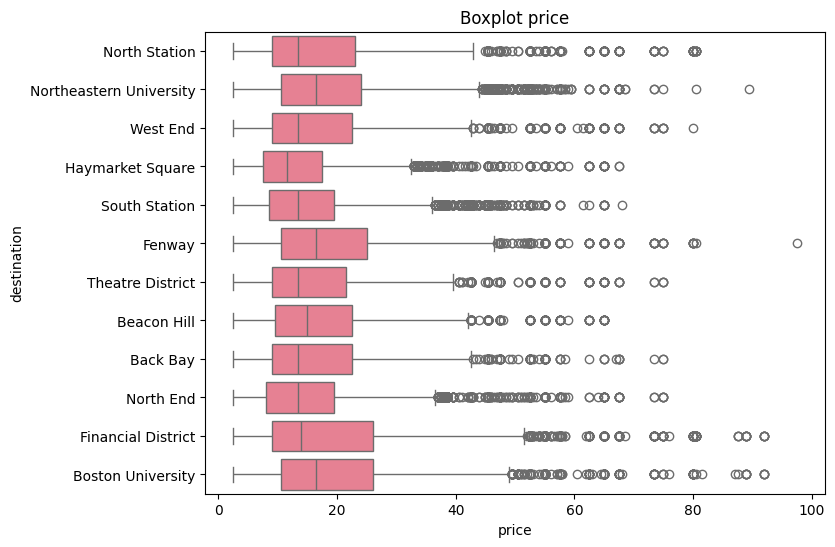

In [125]:
plt.figure(figsize=(8,6))
sns.boxplot(x="price", y="destination", data=df_rides)
plt.title("Boxplot price")
plt.show()

In [126]:
df_rides['distance_int'] = df_rides['distance'].astype('int64') 

In [127]:
df_rides.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,distance_int
0,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,0
1,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,0
2,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,0
3,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,0
4,0.44,Lyft,2018-12-16 08:46:40,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,0


In [129]:
def Distancia_intervalo(distance_int):
    if  (distance_int>=0) & (distance_int<= 1):
        return '[0-1]'
    if  (distance_int> 1) & (distance_int <=2):
        return '[1-2]'
    if (distance_int>2) & (distance_int <= 4):
        return '[2-4]'
    if (distance_int>4) & (distance_int <= 6):
        return '[2-6]'
    else:
        return '[6+]'

In [130]:
df_rides['Distancia_intervalo'] = df_rides.apply(lambda x: Distancia_intervalo(
    distance_int=x['distance_int']), axis=1)

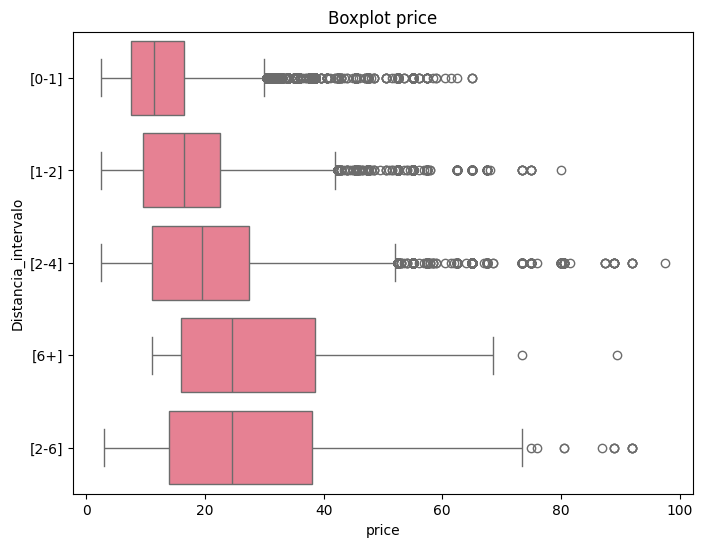

In [131]:

plt.figure(figsize=(8,6))
sns.boxplot(x="price", y="Distancia_intervalo", data=df_rides)
plt.title("Boxplot price")
plt.show()

In [132]:
#Creamos dataframe para los tipos de cab
rides_cab_type_df = pd.DataFrame(df_rides["cab_type"].value_counts()).reset_index()
rides_cab_type_df.rename(columns={"count": "Freq"}, inplace= True)
px.pie(rides_cab_type_df, names = "cab_type", values = "Freq")

### Reflexionar brevemente sobre cómo podrían afectar estos hallazgos el análisis posterior

Durante el análisis se observó que el tipo de servicio "Taxi" se encuentran todos los nulos correspondientes a la columna "price", afecta porque es un tipo de servicio completo sin valor de precio.

Según el destino no se encuentra una relación clara con respecto a los tipos de servicio con precio más alto.

### Interpretar los patrones observados

La mayor cantidad de personas utillizan los servicios de Uber vrs Lyft, siendo Uber el más demandado con un 55.6%


# Exploración inicial del dataset, Evaluación de calidad de datos, Análisis de distribución de variables del Dataset PFDA_weather

In [96]:
# Cargar dataset
df_weather = pd.read_csv('PFDA_weather.csv')

In [98]:
#el dataset tiene 6276 registros y 8 columnas
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [99]:
df_weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


In [ ]:
#transformación time_stamp a tipo datetime
df_weather['time_stamp'] = df_weather['time_stamp'].astype('Int64') 
df_weather['time_stamp'] = pd.to_datetime(df_weather['time_stamp'], unit='s', errors='coerce')
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   temp        6276 non-null   float64      
 1   location    6276 non-null   object       
 2   clouds      6276 non-null   float64      
 3   pressure    6276 non-null   float64      
 4   rain        894 non-null    float64      
 5   time_stamp  6276 non-null   datetime64[s]
 6   humidity    6276 non-null   float64      
 7   wind        6276 non-null   float64      
dtypes: datetime64[s](1), float64(6), object(1)
memory usage: 392.4+ KB


In [103]:
df_weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,2018-12-16 23:45:01,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,2018-12-16 23:45:01,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,2018-12-16 23:45:01,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,2018-12-16 23:45:01,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,2018-12-16 23:45:01,0.75,11.49


In [104]:
#Estadisticas descriptivas del dataset
df_weather[['temp', 'clouds', 'pressure','rain', 'humidity', 'wind']].describe()

,temp,clouds,pressure,rain,humidity,wind
count,6276.000000,6276.000000,6276.000000,894.000000,6276.000000,6276.000000
mean,39.090475,0.677777,1008.445209,0.057652,0.763985,6.802812
std,6.022055,0.314284,12.870775,0.100758,0.127340,3.633466
min,19.620000,0.000000,988.250000,0.000200,0.450000,0.290000
25%,36.077500,0.440000,997.747500,0.004900,0.670000,3.517500
50%,40.130000,0.780000,1007.660000,0.014850,0.760000,6.570000
75%,42.832500,0.970000,1018.480000,0.060925,0.890000,9.920000
max,55.410000,1.000000,1035.120000,0.780700,0.990000,18.180000


In [106]:
# Registros duplicados

df_weather.duplicated().sum()

np.int64(0)

In [105]:
# Valores nulos por columna - WEATHER
null_weather = df_weather.isnull().sum()
null_weather_pct = (df_weather.isnull().sum() / len(df_weather)) * 100
null_summary_weather = pd.DataFrame({
    'Valores_Nulos': null_weather,
    'Porcentaje_Nulos': null_weather_pct.round(2)
})
null_summary_weather.sort_values(by='Porcentaje_Nulos', ascending=False)

,Valores_Nulos,Porcentaje_Nulos
rain,5382,85.76
temp,0,0.00
clouds,0,0.00
location,0,0.00
pressure,0,0.00
time_stamp,0,0.00
humidity,0,0.00
wind,0,0.00


In [107]:
#rain por location
location_rain = df_weather.groupby("location")['rain'].agg(['count','mean','median','std', 'min','max'])
location_rain

,count,mean,median,std,min,max
location,,,,,,
Back Bay,74,0.056012,0.01415,0.095698,0.0020,0.6364
Beacon Hill,76,0.057097,0.01385,0.101059,0.0006,0.6930
Boston University,74,0.054688,0.01510,0.087766,0.0017,0.5520
Fenway,70,0.054863,0.01600,0.084972,0.0020,0.5337
Financial District,73,0.061352,0.01600,0.111081,0.0002,0.7753
Haymarket Square,76,0.059593,0.01480,0.109099,0.0003,0.7625
North End,77,0.058712,0.01400,0.109702,0.0006,0.7807
North Station,80,0.056542,0.01270,0.103807,0.0003,0.7247
Northeastern University,71,0.054197,0.01430,0.088124,0.0020,0.5659


In [108]:
#rain por location
df_weather[df_weather['rain'].isnull()]

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
11,43.28,Back Bay,0.81,990.81,NaN,2018-11-27 19:45:20,0.71,8.30
12,43.27,Beacon Hill,0.80,990.80,NaN,2018-11-27 19:45:20,0.71,8.30
13,43.35,Boston University,0.82,990.82,NaN,2018-11-27 19:45:20,0.71,8.24
14,43.07,Fenway,0.82,990.82,NaN,2018-11-27 19:45:20,0.72,8.28
15,43.35,Financial District,0.80,990.80,NaN,2018-11-27 19:45:20,0.71,8.35
...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,NaN,2018-12-03 06:52:54,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,NaN,2018-12-03 06:52:54,0.96,1.54
6273,44.82,South Station,0.89,1000.70,NaN,2018-12-03 06:52:54,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,NaN,2018-12-03 06:52:54,0.96,1.54


In [ ]:
#verificar outliers weather con temperatura
Q1 = df_weather['temp'].quantile(0.25)
Q3 = df_weather['temp'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior= Q1 - (1.5*IQR)
limite_superior= Q3 + (1.5*IQR)

outliers_weather = df_weather[(df_weather['temp'] < limite_inferior) | (df_weather['temp'] > limite_superior)]
outliers_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
134,25.40,Back Bay,0.76,1006.33,NaN,2018-12-18 10:45:01,0.52,17.96
135,25.70,Beacon Hill,0.80,1006.69,NaN,2018-12-18 10:45:01,0.53,17.88
136,25.50,Boston University,0.79,1006.25,NaN,2018-12-18 10:45:01,0.52,17.81
137,25.74,Financial District,0.77,1006.30,NaN,2018-12-18 10:45:01,0.52,18.11
138,25.37,Haymarket Square,0.77,1006.30,NaN,2018-12-18 10:45:01,0.53,18.16
...,...,...,...,...,...,...,...,...
6084,25.27,Haymarket Square,0.51,1009.35,NaN,2018-12-18 13:45:01,0.49,13.06
6085,25.29,North End,0.51,1009.35,NaN,2018-12-18 13:45:01,0.49,13.08
6086,25.29,North Station,0.51,1009.36,NaN,2018-12-18 13:45:01,0.49,13.04
6087,25.29,Northeastern University,0.51,1009.37,NaN,2018-12-18 13:45:01,0.49,12.89


In [114]:
#verificar outliers weather con clouds
Q1 = df_weather['clouds'].quantile(0.25)
Q3 = df_weather['clouds'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior= Q1 - (1.5*IQR)
limite_superior= Q3 + (1.5*IQR)

outliers_weather = df_weather[(df_weather['clouds'] < limite_inferior) | (df_weather['clouds'] > limite_superior)]
outliers_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind


In [115]:
#verificar outliers weather con pressure
Q1 = df_weather['pressure'].quantile(0.25)
Q3 = df_weather['pressure'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior= Q1 - (1.5*IQR)
limite_superior= Q3 + (1.5*IQR)

outliers_weather = df_weather[(df_weather['pressure'] < limite_inferior) | (df_weather['pressure'] > limite_superior)]
outliers_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind


In [116]:
#verificar outliers weather con humidity
Q1 = df_weather['humidity'].quantile(0.25)
Q3 = df_weather['humidity'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior= Q1 - (1.5*IQR)
limite_superior= Q3 + (1.5*IQR)

outliers_weather = df_weather[(df_weather['humidity'] < limite_inferior) | (df_weather['humidity'] > limite_superior)]
outliers_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind


In [117]:
#verificar outliers weather con wind
Q1 = df_weather['wind'].quantile(0.25)
Q3 = df_weather['wind'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior= Q1 - (1.5*IQR)
limite_superior= Q3 + (1.5*IQR)

outliers_weather = df_weather[(df_weather['wind'] < limite_inferior) | (df_weather['wind'] > limite_superior)]
outliers_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind


In [ ]:
#Hacemos un diagrama de barras para los ubicación
weather_location_df = pd.DataFrame(df_weather.groupby("location")["rain"].mean()).reset_index()
weather_location_df = weather_location_df.sort_values(by = "rain", ascending= False)
px.bar(weather_location_df, x = "location", y = "rain")

In [134]:
num_cols = [ "rain"]

# Convertir el dataset (df_rides) de formato ancho a largo
df_long = df_weather.melt(value_vars=num_cols, var_name="Variable", value_name="Valor")

# Crear histograma
fig = px.histogram(
    df_long,
    x="Valor",
    color="Variable",     # diferencia por color
    nbins=30,
    barmode="overlay",    # puedes usar "stack" o "group"
    title="Distribución de variables del clima"
)

fig.show()

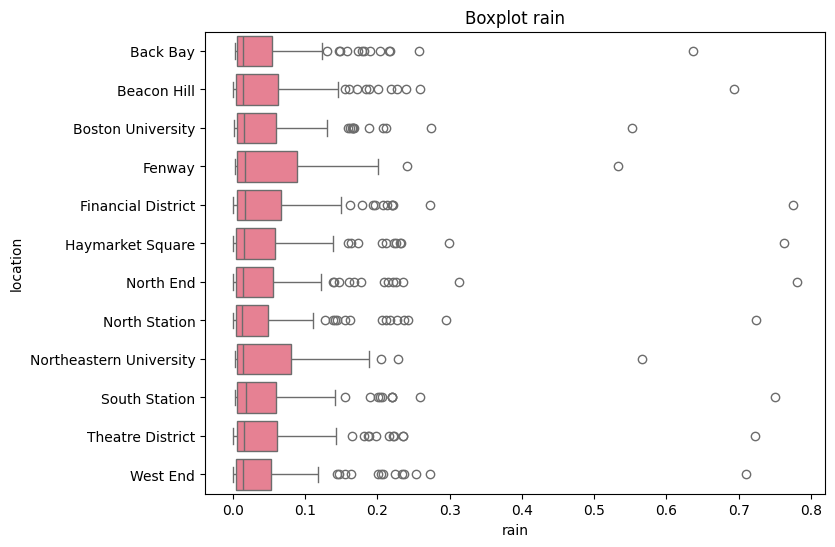

In [121]:
#graficos
# para weather
plt.figure(figsize=(8,6))
sns.boxplot(x="rain", y="location", data=df_weather)
plt.title("Boxplot rain")
plt.show()

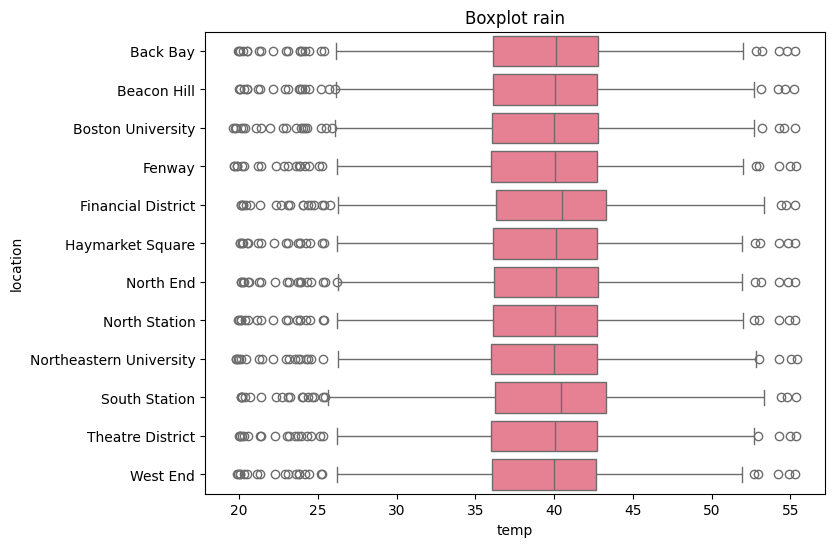

In [135]:
#graficos
# para weather
plt.figure(figsize=(8,6))
sns.boxplot(x="temp", y="location", data=df_weather)
plt.title("Boxplot rain")
plt.show()

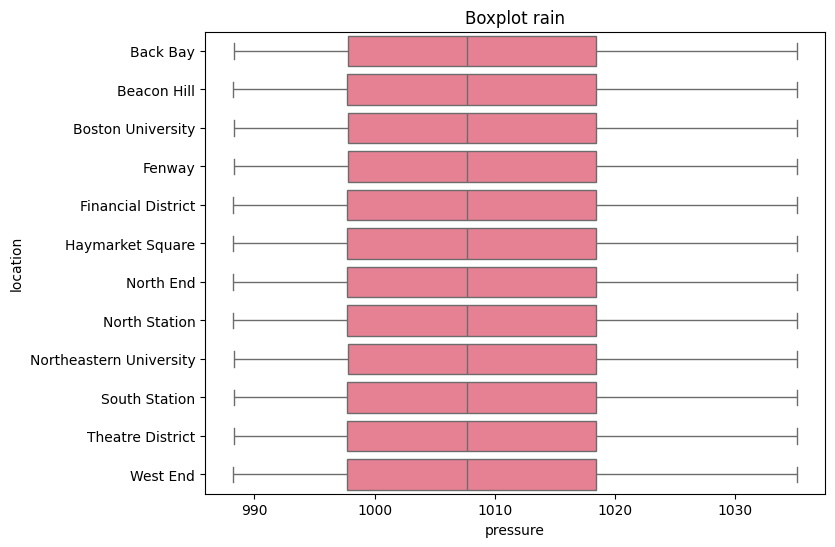

In [136]:
#graficos
# para weather
plt.figure(figsize=(8,6))
sns.boxplot(x="pressure", y="location", data=df_weather)
plt.title("Boxplot rain")
plt.show()

### Reflexionar brevemente sobre cómo podrían afectar estos hallazgos el análisis posterior

Al tener un alto porcentaje de nulos en la columna "rain" afecta en el análisis de demanda de tranporte y no se puede corroborar dicha hipotesis ya que nos se cuenta con los suficientes datos que den la confianza suficiente para poder emitir una disición acertada.

Al tener la variable de presión un valor de desviación estandar de 12. .. , indica que los datos están dispersos con respecto a la media y en consecuencia existe una gran variabilidad.

### Interpretar los patrones observados

En la columna de humedad la media tiene un valor de: 0.763985 y la mediana un valor de: 0.760000 se llega a la conclusión que su distribución es simetrica y posiblemente no tiene valores atípicos.

Se encuentra que los outliers en la columna temperatura son valores que podrían corresponder a cierta horas específicas, por ejemplo, muy en la mañana o muy en la noche.